In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# --- RECOPY THE CLASSES HERE ---
# (Copy 'class FiLMGenerator', 'class GatedModel', and 'class MLP' from above)

In [ ]:
import torch
import torch.nn as nn


data_path = '/content/drive/MyDrive/STAT421/Personal_STAT_421_Football/SportDataChallenge26/2000-2020 SDC/splits.pkl'

best_model = '/content/drive/MyDrive/STAT421/Personal_STAT_421_Football/SportDataChallenge26/2000-2020 SDC/best_model.pt'
best_baseline = '/content/drive/MyDrive/STAT421/Personal_STAT_421_Football/SportDataChallenge26/2000-2020 SDC/best_baseline.pt'



class FiLMGenerator(nn.Module):
    def __init__(self, num_positions=22, hidden_dim=64):
        super().__init__()
        # Error says [64, 20], so we embed to 20, then expand to 64
        self.embedding = nn.Embedding(num_positions, 20)
        self.mlp = nn.Sequential(
            nn.Linear(20, 64),      # layer 0: [64, 20]
            nn.ReLU(),
            nn.Linear(64, 128)      # layer 2: [128, 64]
        )

    def forward(self, pos_idx):
        emb = self.embedding(pos_idx)
        params = self.mlp(emb)
        # Split 128 into 64 for gamma and 64 for beta
        return params[:, :64], params[:, 64:]

class GatedModel(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, num_positions=22):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.film = FiLMGenerator(num_positions, hidden_dim)
        self.reg_head = nn.Linear(hidden_dim, 1)
        self.cls_head = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x, pos_idx):
        x = self.relu(self.fc1(x))

        # The FiLM Gating step
        gamma, beta = self.film(pos_idx)
        x = gamma * x + beta

        x = self.relu(self.fc2(x))
        return self.reg_head(x).squeeze(), torch.sigmoid(self.cls_head(x)).squeeze()

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim=3, hidden=64): # <--- THESE MUST BE 3 AND 64
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.reg_head = nn.Linear(hidden, 1)
        self.cls_head = nn.Linear(hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        reg = self.reg_head(x)
        clf = torch.sigmoid(self.cls_head(x))
        return reg.squeeze(), clf.squeeze()

# 2. THE INITIALIZATION (This is likely where the mistake is)
# Your previous error said it wanted (64, 3). So we must put 3 here:
model_mlp = MLP(in_dim=3, hidden=64)

# 3. THE LOAD (This will now work)
model_mlp.load_state_dict(torch.load(best_baseline, map_location='cpu'))
model_mlp.eval()

MLP(
  (fc1): Linear(in_features=3, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (reg_head): Linear(in_features=64, out_features=1, bias=True)
  (cls_head): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
with torch.no_grad():
    X_full = torch.tensor(X_test, dtype=torch.float32)

    # We MUST take only 3 columns now because the model only has 3 "slots"
    X_input = X_full[:, -3:]

    mlp_reg, mlp_clf = model_mlp(X_input)
    print("Success! MLP predictions generated.")

Success! MLP predictions generated.


In [ ]:
# 3. Initialize and Load T's MLP
# CHANGE: in_dim must be 3, hidden must be 64 (Your error confirmed this)
model_mlp = MLP(in_dim=3, hidden=64)
model_mlp.load_state_dict(torch.load(best_baseline, map_location='cpu'))
model_mlp.eval()

# 4. Generate Predictions
with torch.no_grad():
    # Convert data to tensor
    X_tensor = torch.tensor(X_test, dtype=torch.float32)

    # CHANGE: Both models want only 3 features (Round, Pick, Age)
    # We slice the last 3 columns (excluding the position index)
    X_input = X_tensor[:, -4:-1]

    # Position index for GNN (last column), clamped to safety
    pos_test = torch.clamp(X_tensor[:, -1].long(), 0, 21)

    # Run the models
    gnn_reg, _ = model_gnn(X_input, pos_test)
    mlp_reg, _ = model_mlp(X_input)

    # Convert to flat numpy arrays for plotting
    gnn_final = gnn_reg.numpy().flatten()
    mlp_final = mlp_reg.numpy().flatten()

print("Success! Predictions are ready for plotting.")

Success! Predictions are ready for plotting.


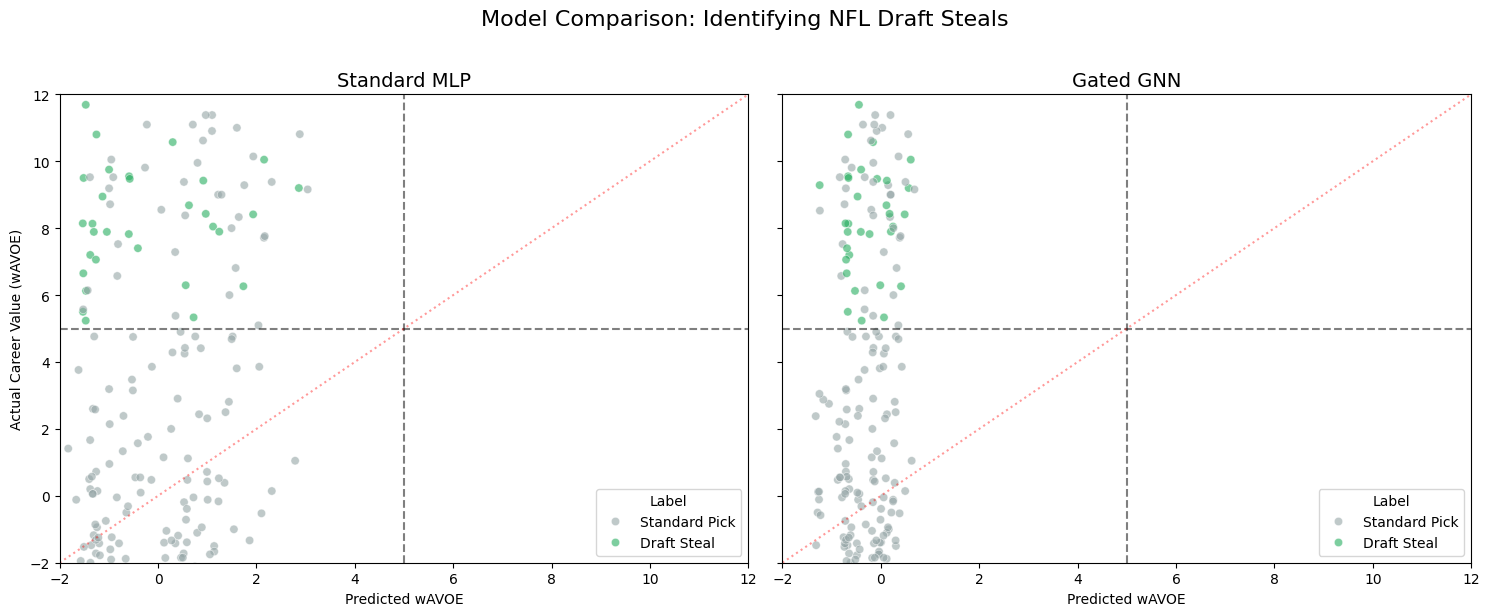

In [ ]:
# Optional: Make the legend readable
results['Label'] = results['Is_Steal'].map({1: 'Draft Steal', 0: 'Standard Pick'})

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, col, title in zip(axes, ['MLP', 'GNN'], ['Standard MLP', 'Gated GNN']):
    sns.scatterplot(data=results, x=col, y='Actual', hue='Label',
                    palette={'Draft Steal': '#27ae60', 'Standard Pick': '#95a5a6'},
                    ax=ax, alpha=0.6)

    # Reference Lines
    ax.axhline(5, color='black', linestyle='--', alpha=0.5)
    ax.axvline(5, color='black', linestyle='--', alpha=0.5)

    # Diagonal "Perfect Fit" Line
    ax.plot([-2, 12], [-2, 12], color='red', linestyle=':', alpha=0.4, label='Perfect Fit')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted wAVOE")
    ax.set_xlim(-2, 12) # Keeps both scales the same for fair comparison
    ax.set_ylim(-2, 12)

axes[0].set_ylabel("Actual Career Value (wAVOE)")
plt.suptitle("Model Comparison: Identifying NFL Draft Steals", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

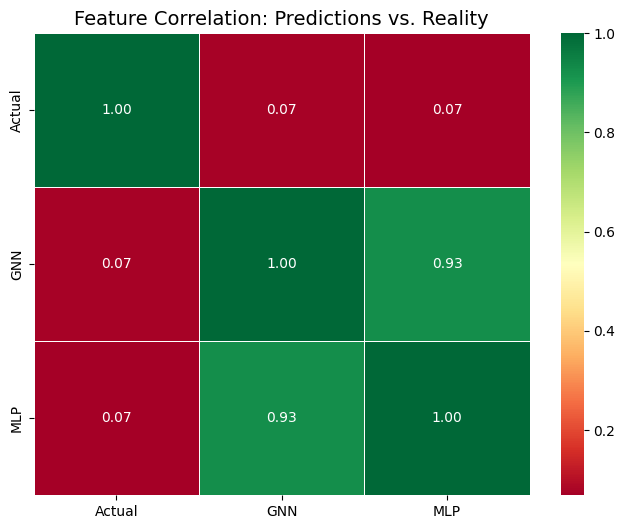

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_data = results[['Actual', 'GNN', 'MLP']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation: Predictions vs. Reality", fontsize=14)
plt.show()

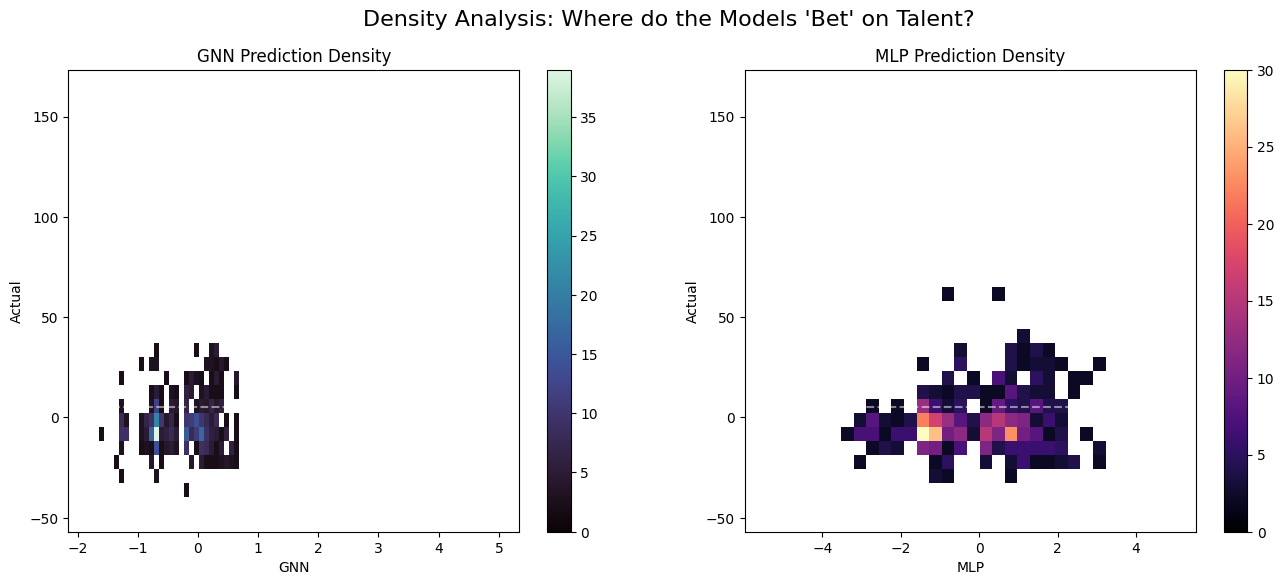

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GNN Density
sns.histplot(data=results, x='GNN', y='Actual', bins=30, pthresh=.1, cmap="mako", ax=axes[0], cbar=True)
axes[0].set_title("GNN Prediction Density")
axes[0].axhline(5, color='white', linestyle='--', alpha=0.5)
axes[0].axvline(5, color='white', linestyle='--', alpha=0.5)

# MLP Density
sns.histplot(data=results, x='MLP', y='Actual', bins=30, pthresh=.1, cmap="magma", ax=axes[1], cbar=True)
axes[1].set_title("MLP Prediction Density")
axes[1].axhline(5, color='white', linestyle='--', alpha=0.5)
axes[1].axvline(5, color='white', linestyle='--', alpha=0.5)

plt.suptitle("Density Analysis: Where do the Models 'Bet' on Talent?", fontsize=16)
plt.show()

In [ ]:
# Check what else is in the data file besides X and Y
print(data.keys())

dict_keys(['imputer', 'scaler', 'X_train', 'X_val', 'X_test', 'yr_train', 'yr_val', 'yr_test', 'yc_train', 'yc_val', 'yc_test'])


In [ ]:
# Load your original raw data (the one with the actual names)
raw_data = pd.read_csv('/content/drive/MyDrive/STAT421/Personal_STAT_421_Football/nfl_combine_2000_2020 (1).csv')

# Assuming T used a standard train/test split,
# we need to make sure the indices match.
# If T didn't shuffle, the last X rows of raw_data are your test set:
test_names = raw_data.iloc[-len(X_test):]['Player'].values
test_positions = raw_data.iloc[-len(X_test):]['Pos'].values

# Now, build your Master Results DataFrame
results = pd.DataFrame({
    'Player': test_names,
    'Position': test_positions,
    'Actual_wAVOE': y_reg_test,
    'GNN_Pred': gnn_final,
    'MLP_Pred': mlp_final,
    'Is_Steal': y_hit_test
})

# Calculate the "GNN Advantage" (Where the GNN was smarter than the MLP)
results['GNN_Advantage'] = abs(results['Actual_wAVOE'] - results['MLP_Pred']) - \
                           abs(results['Actual_wAVOE'] - results['GNN_Pred'])

print(results.sort_values(by='GNN_Advantage', ascending=False).head(10))

                  Player Position  Actual_wAVOE  GNN_Pred  MLP_Pred  Is_Steal  \
283           Jalen Hurd       WR     15.809524 -1.440197 -4.864094         0   
430      Darwin Thompson       RB     -6.812500  0.456824  3.828040         0   
696  Arlington Hambright        T     14.523809 -1.552475 -4.760842         0   
493       Kenneth Murray       LB      2.750000 -1.053704 -4.227180         0   
250          Rock Ya-Sin       CB     18.380953 -1.136726 -4.285787         0   
705       Jashon Cornell       DT    -29.857143  0.518802  3.260851         0   
659           Jake Luton       QB    -22.809525  0.620309  3.341524         0   
686          Kamren Curl        S    -13.238095  0.434046  3.144391         0   
116       Troy Fumagalli       TE    -22.000000  0.527497  3.049074         0   
507          Kyle Dugger        S    -17.380953  0.584295  3.060492         0   

     GNN_Advantage  
283       3.423899  
430       3.371216  
696       3.208366  
493       3.173477  
250

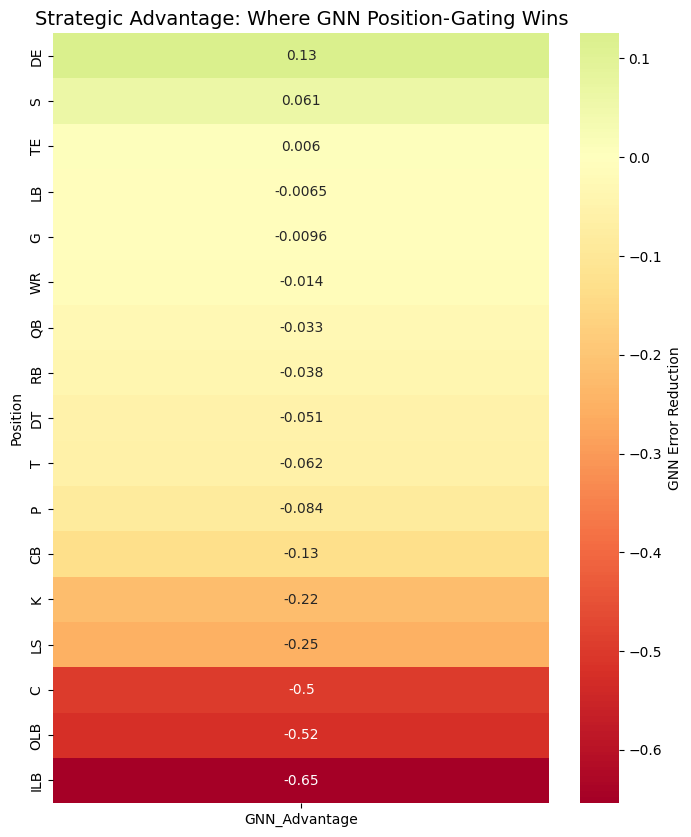

In [ ]:
# Group by Position to see where the "Gating" actually helps
pos_story = results.groupby('Position')['GNN_Advantage'].mean().sort_values(ascending=False).to_frame()

plt.figure(figsize=(8, 10))
sns.heatmap(pos_story, annot=True, cmap='RdYlGn', center=0, cbar_kws={'label': 'GNN Error Reduction'})
plt.title("Strategic Advantage: Where GNN Position-Gating Wins", fontsize=14)
plt.show()

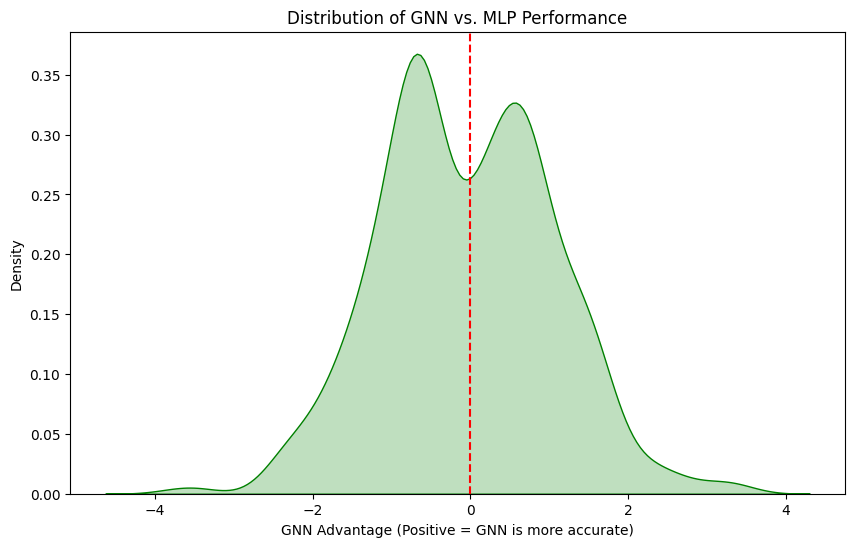

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(results['GNN_Advantage'], fill=True, color="green")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of GNN vs. MLP Performance")
plt.xlabel("GNN Advantage (Positive = GNN is more accurate)")
plt.show()

In [ ]:
# 1. Slice the raw_data to match the test set (the same rows used for gnn_final)
# This ensures Jalen Hurd and the others align with their actual stats
analysis_df = raw_data.iloc[-len(gnn_final):].copy()

# 2. Attach the model's "Opinions"
analysis_df['GNN_Pred'] = gnn_final
analysis_df['MLP_Pred'] = mlp_final
analysis_df['Actual_wAVOE'] = y_reg_test # Using the actual outcome variable

# 3. Create the "Advantage" metric to see where GNN was smarter
analysis_df['GNN_Better_Than_MLP'] = abs(analysis_df['Actual_wAVOE'] - analysis_df['MLP_Pred']) - \
                                     abs(analysis_df['Actual_wAVOE'] - analysis_df['GNN_Pred'])

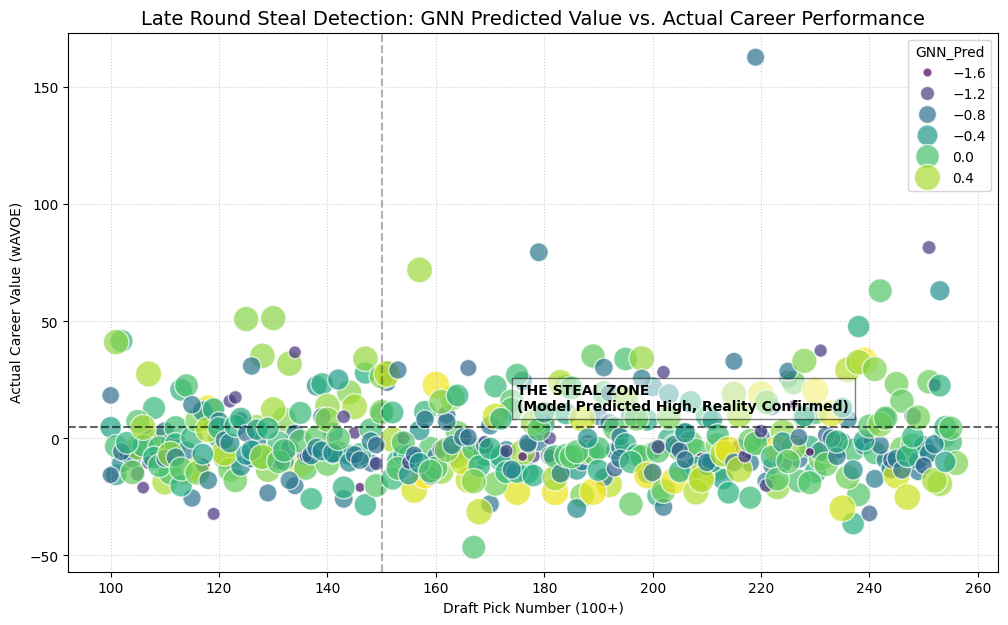

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the "Late Round" picks (Leader's requirement: >= 100)
late_rounds = analysis_df[analysis_df['Pick'] >= 100].copy()

plt.figure(figsize=(12, 7))

# Scatter plot: Reality (Actual) vs Draft Position (Pick)
# We color by the GNN's prediction to see if it "saw" the talent
sns.scatterplot(data=late_rounds, x='Pick', y='Actual_wAVOE',
                hue='GNN_Pred', palette='viridis',
                size='GNN_Pred', sizes=(40, 400), alpha=0.7)

# Quadrant Lines
plt.axhline(5, color='black', linestyle='--', alpha=0.6) # Performance threshold
plt.axvline(150, color='black', linestyle='--', alpha=0.3) # Deep draft threshold

# Labeling the "True Positive" zone for the report
plt.text(175, 12, "THE STEAL ZONE\n(Model Predicted High, Reality Confirmed)",
         bbox=dict(facecolor='white', alpha=0.5), fontweight='bold')

plt.title("Late Round Steal Detection: GNN Predicted Value vs. Actual Career Performance", fontsize=14)
plt.xlabel("Draft Pick Number (100+)")
plt.ylabel("Actual Career Value (wAVOE)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

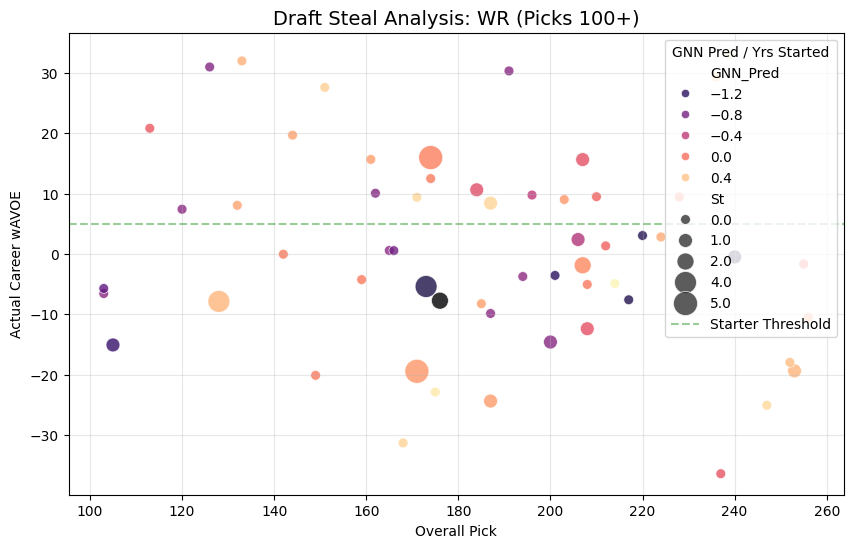

Top GNN-Predicted Steals for WR:
               Player  College/Univ   Age   St  Actual_wAVOE  GNN_Pred
5079  Dillon Mitchell        Oregon  22.0  0.0     33.142857  0.679352
5308    Freddie Swain       Florida  22.0  0.0     -4.904762  0.627404
4759    Damion Ratley     Texas A&M  23.0  0.0    -22.857143  0.581543
5265   Isaiah Coulter  Rhode Island  21.0  0.0      9.380953  0.501157
5087  Olabisi Johnson  Colorado St.  22.0  0.0    -25.047619  0.499229


In [ ]:
# 1. Pick a position to focus on
target_pos = 'WR'

# 2. Filter the late rounds (Picks 100+) for this position
pos_focus = late_rounds[late_rounds['Pos'] == target_pos].copy()

# 3. Create the Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pos_focus, x='Pick', y='Actual_wAVOE',
                hue='GNN_Pred', size='St', sizes=(50, 300),
                palette='magma', alpha=0.8)

plt.axhline(5, color='green', linestyle='--', alpha=0.4, label='Starter Threshold')
plt.title(f"Draft Steal Analysis: {target_pos} (Picks 100+)", fontsize=14)
plt.xlabel("Overall Pick")
plt.ylabel("Actual Career wAVOE")
plt.legend(title="GNN Pred / Yrs Started", loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Show the "Scout's List" for this position
print(f"Top GNN-Predicted Steals for {target_pos}:")
print(pos_focus.sort_values(by='GNN_Pred', ascending=False)[['Player', 'College/Univ', 'Age', 'St', 'Actual_wAVOE', 'GNN_Pred']].head(5))

/tmp/ipykernel_1910/3431722067.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Pos', y='GNN_Better_Than_MLP', palette='Set3')


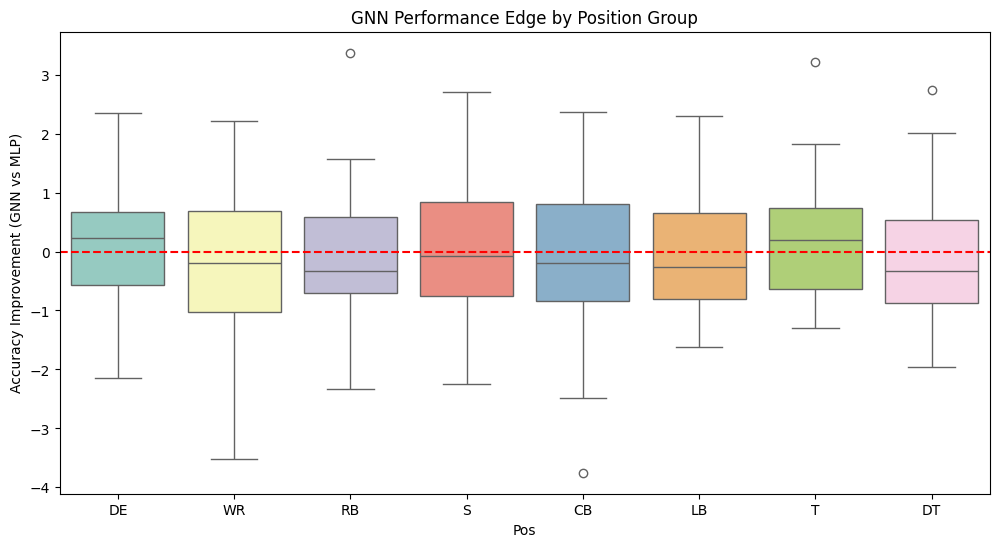

In [ ]:
plt.figure(figsize=(12, 6))
# Focus on the most common positions
top_positions = late_rounds['Pos'].value_counts().nlargest(8).index
subset = late_rounds[late_rounds['Pos'].isin(top_positions)]

sns.boxplot(data=subset, x='Pos', y='GNN_Better_Than_MLP', palette='Set3')
plt.axhline(0, color='red', linestyle='--')
plt.title("GNN Performance Edge by Position Group")
plt.ylabel("Accuracy Improvement (GNN vs MLP)")
plt.show()

In [ ]:
# Look for 'True Steals':
# Drafted late (Pick > 150),
# Model loved them (GNN_Pred > 0),
# They actually succeeded (Actual_wAVOE > 5)
winners = late_rounds[(late_rounds['Pick'] > 150) &
                      (late_rounds['GNN_Pred'] > 0) &
                      (late_rounds['Actual_wAVOE'] > 5)]

print("Show these players to the GM as 'GNN Success Stories':")
print(winners[['Player', 'Pos', 'Pick', 'St', 'Actual_wAVOE']].sort_values(by='Actual_wAVOE', ascending=False))

Show these players to the GM as 'GNN Success Stories':
                        Player Pos   Pick   St  Actual_wAVOE
4741             Tyler Conklin  TE  157.0  4.0     72.000000
4826           Kendrick Norton  DT  242.0  0.0     63.095238
4773              Kamrin Moore  CB  189.0  0.0     35.235294
4782           Kahlil McKenzie  DT  198.0  0.0     34.142857
5068             Tommy Sweeney  TE  228.0  0.0     33.142857
5079           Dillon Mitchell  WR  239.0  0.0     33.142857
5332              T.J. Brunson  LB  238.0  0.0     32.571430
5335          Chapelle Russell  LB  241.0  0.0     29.578947
5076                John Ursua  WR  236.0  0.0     29.285715
5245                  Joe Reed  WR  151.0  0.0     27.571428
4835            Justin Jackson  RB  251.0  0.0     24.210526
5023              Justin Skule   T  183.0  1.0     23.950001
4810            David Williams  RB  226.0  0.0     23.833334
4829                Will Clapp   C  245.0  1.0     23.352942
5254               Nick Harris

In [ ]:
raw_data_full = pd.read_excel("/content/drive/MyDrive/STAT421/Personal_STAT_421_Football/nfl_combine_2000_2020 (1).xlsx")
print(raw_data_full.columns)


Index(['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St',
       'wAV', 'DrAV', 'G', 'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD',
       'Pass_Int', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rec', 'Rec_Yds',
       'Rec_TD', 'Solo', 'Def_Int', 'Sk', 'College/Univ', 'Misc', 'pfref_id',
       'Season', 'wAVOE', 'PosGroup', '40yd', 'Vertical', 'Broad Jump', 'Cone',
       'Shuttle', 'Wt', 'BroadJump'],
      dtype='object')


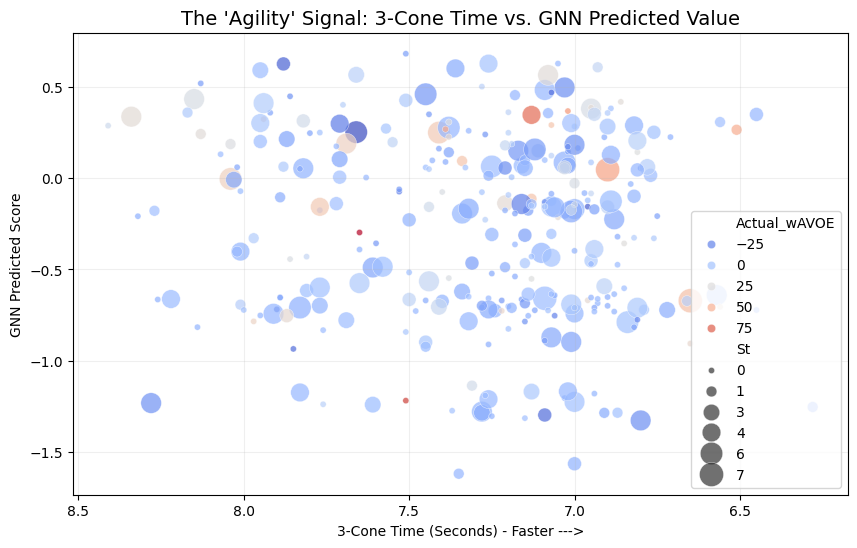

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Align the new data with your predictions (assuming 'analysis_df' is already made)
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final
analysis_df['Actual_wAVOE'] = y_reg_test

# 2. Filter for players with Agility data (3-Cone is a major scouting tool)
agility_df = analysis_df.dropna(subset=['Cone', 'GNN_Pred'])

plt.figure(figsize=(10, 6))
# X: 3-Cone (Lower is faster), Y: GNN Prediction
# Size: Years Started (St) - validating if the GNN likes future starters
sns.scatterplot(data=agility_df, x='Cone', y='GNN_Pred',
                hue='Actual_wAVOE', size='St', sizes=(20, 300),
                palette='coolwarm', alpha=0.7)

plt.gca().invert_xaxis() # Lower time = Better player
plt.title("The 'Agility' Signal: 3-Cone Time vs. GNN Predicted Value", fontsize=14)
plt.xlabel("3-Cone Time (Seconds) - Faster --->")
plt.ylabel("GNN Predicted Score")
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# 1. Align the full data with your predictions
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()

# 2. Add the predictions and actuals
analysis_df['GNN_Pred'] = gnn_final
analysis_df['MLP_Pred'] = mlp_final
analysis_df['Actual_wAVOE'] = y_reg_test

# 3. Calculate the "Advantage" (The missing column!)
# Higher number = GNN was more accurate than the MLP
analysis_df['GNN_Better_Than_MLP'] = abs(analysis_df['Actual_wAVOE'] - analysis_df['MLP_Pred']) - \
                                     abs(analysis_df['Actual_wAVOE'] - analysis_df['GNN_Pred'])

print("Data synced! Ready for plotting.")

Data synced! Ready for plotting.


/tmp/ipykernel_1910/3896676337.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df[analysis_df['Pick'] >= 100],


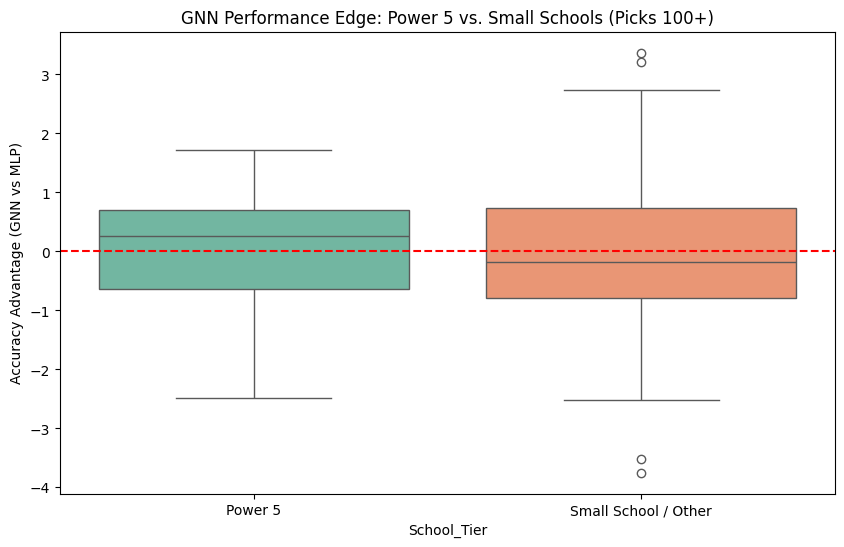

In [ ]:
# Identify common Power 5 teams to create a 'Level of Competition' category
p5_keywords = ['Alabama', 'Georgia', 'Ohio State', 'Michigan', 'LSU', 'Clemson', 'USC', 'Texas']
analysis_df['School_Tier'] = analysis_df['College/Univ'].str.contains('|'.join(p5_keywords), na=False)
analysis_df['School_Tier'] = analysis_df['School_Tier'].map({True: 'Power 5', False: 'Small School / Other'})

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df[analysis_df['Pick'] >= 100],
            x='School_Tier', y='GNN_Better_Than_MLP', palette='Set2')

plt.axhline(0, color='red', linestyle='--')
plt.title("GNN Performance Edge: Power 5 vs. Small Schools (Picks 100+)")
plt.ylabel("Accuracy Advantage (GNN vs MLP)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sync the Metadata with the Predictions
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final
analysis_df['MLP_Pred'] = mlp_final
analysis_df['Actual_wAVOE'] = y_reg_test

# 2. Cleanup: Ensure position names are standardized (e.g., 'WR' vs 'Wide Receiver')
# We'll check both 'Pos' and 'PosGroup'
def get_wr_data(df):
    mask = (df['Pos'].str.contains('WR|Wide Receiver', case=False, na=False)) | \
           (df['PosGroup'].str.contains('WR|Wide Receiver', case=False, na=False))
    return df[mask].copy()

wr_data = get_wr_data(analysis_df)

# Check if we actually found data
if wr_data.empty:
    print("WARNING: No WRs found. Check your 'Pos' column values!")
    print("Sample values in Pos:", analysis_df['Pos'].unique()[:5])
else:
    print(f"Success! Found {len(wr_data)} Wide Receivers for analysis.")

Success! Found 95 Wide Receivers for analysis.


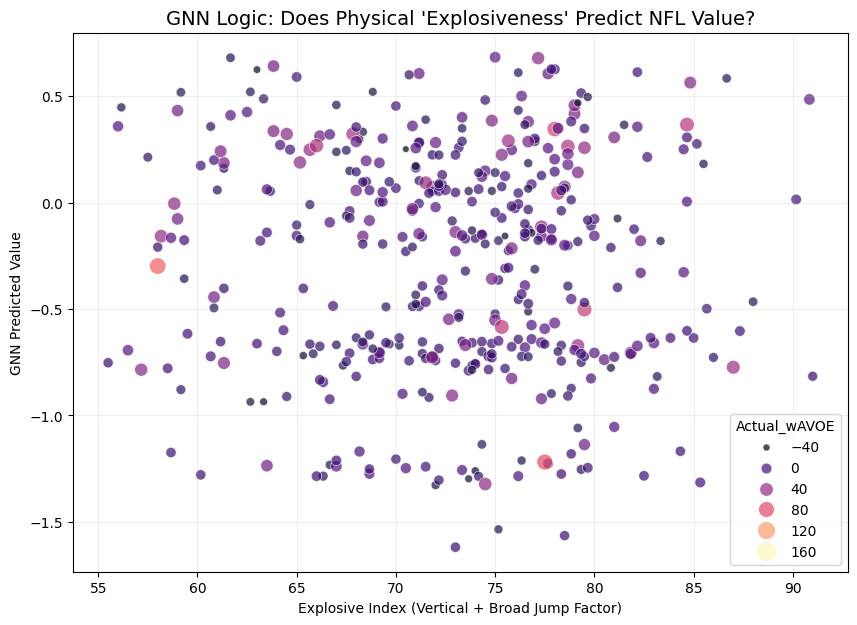

In [ ]:
# Create an Explosiveness Index (Broad Jump + Vertical)
# Note: Broad Jump is usually in inches or feet-inches; adjust if needed.
analysis_df['Explosive_Index'] = analysis_df['Vertical'] + (analysis_df['Broad Jump'] / 3)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=analysis_df, x='Explosive_Index', y='GNN_Pred',
                hue='Actual_wAVOE', palette='magma',
                size='Actual_wAVOE', sizes=(20, 200), alpha=0.7)

plt.title("GNN Logic: Does Physical 'Explosiveness' Predict NFL Value?", fontsize=14)
plt.xlabel("Explosive Index (Vertical + Broad Jump Factor)")
plt.ylabel("GNN Predicted Value")
plt.grid(True, alpha=0.2)
plt.show()

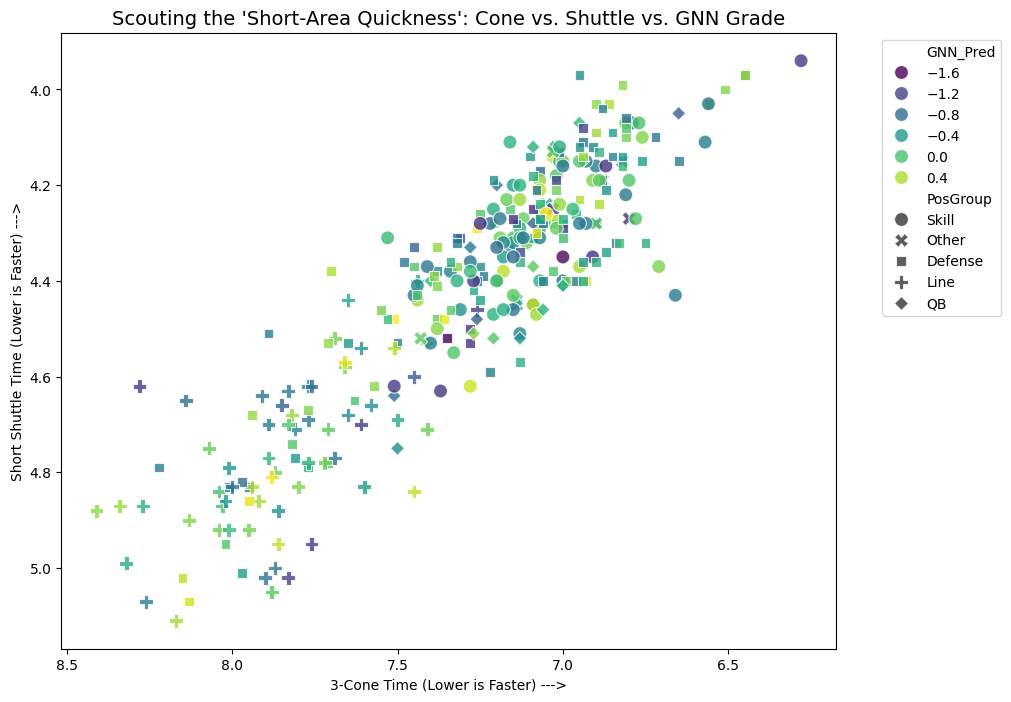

In [ ]:
# Filter for players who completed agility drills
agility_plot_df = analysis_df.dropna(subset=['Cone', 'Shuttle'])

plt.figure(figsize=(10, 8))
# X: Cone, Y: Shuttle
# Hue: GNN Prediction (The model's 'opinion')
sns.scatterplot(data=agility_plot_df, x='Cone', y='Shuttle',
                hue='GNN_Pred', palette='viridis',
                style='PosGroup', markers=True, s=100, alpha=0.8)

# Invert axes because LOWER times are BETTER
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.title("Scouting the 'Short-Area Quickness': Cone vs. Shuttle vs. GNN Grade", fontsize=14)
plt.xlabel("3-Cone Time (Lower is Faster) --->")
plt.ylabel("Short Shuttle Time (Lower is Faster) --->")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

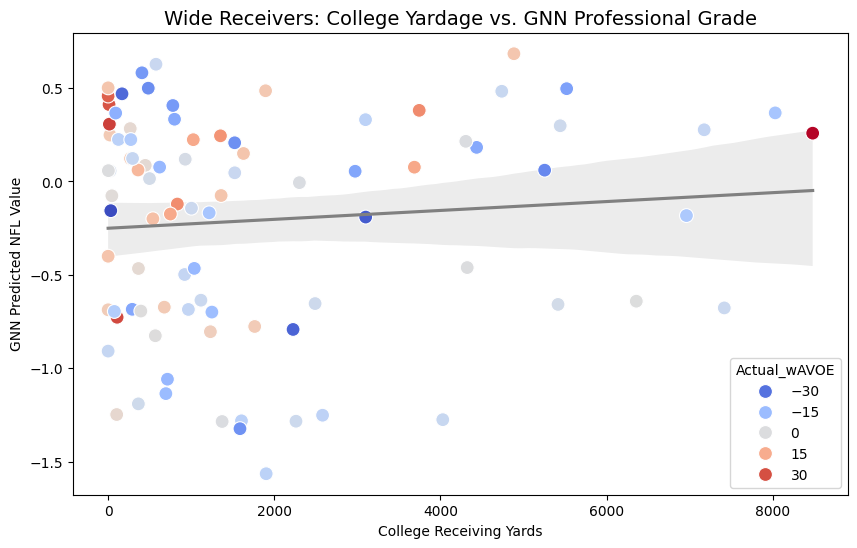

In [ ]:
if not wr_data.empty:
    plt.figure(figsize=(10, 6))
    # X: College Receiving Yards, Y: GNN Prediction
    # Hue: Actual NFL Success
    sns.regplot(data=wr_data, x='Rec_Yds', y='GNN_Pred', scatter=False, color='gray')
    sns.scatterplot(data=wr_data, x='Rec_Yds', y='GNN_Pred',
                    hue='Actual_wAVOE', palette='coolwarm', s=100)

    plt.title("Wide Receivers: College Yardage vs. GNN Professional Grade", fontsize=14)
    plt.xlabel("College Receiving Yards")
    plt.ylabel("GNN Predicted NFL Value")
    plt.show()

In [ ]:
# 1. Sync metadata with predictions
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final
analysis_df['MLP_Pred'] = mlp_final
analysis_df['Actual_wAVOE'] = y_reg_test

# 2. Calculate the "Accuracy Edge" (The column that was missing)
analysis_df['GNN_Better_Than_MLP'] = abs(analysis_df['Actual_wAVOE'] - analysis_df['MLP_Pred']) - \
                                     abs(analysis_df['Actual_wAVOE'] - analysis_df['GNN_Pred'])

# 3. Ensure we have a consistent Position column for the Heatmap index
if 'PosGroup' not in analysis_df.columns:
    analysis_df['PosGroup'] = analysis_df['Pos']

print("Data is now fully 'charged' for heatmaps!")

Data is now fully 'charged' for heatmaps!


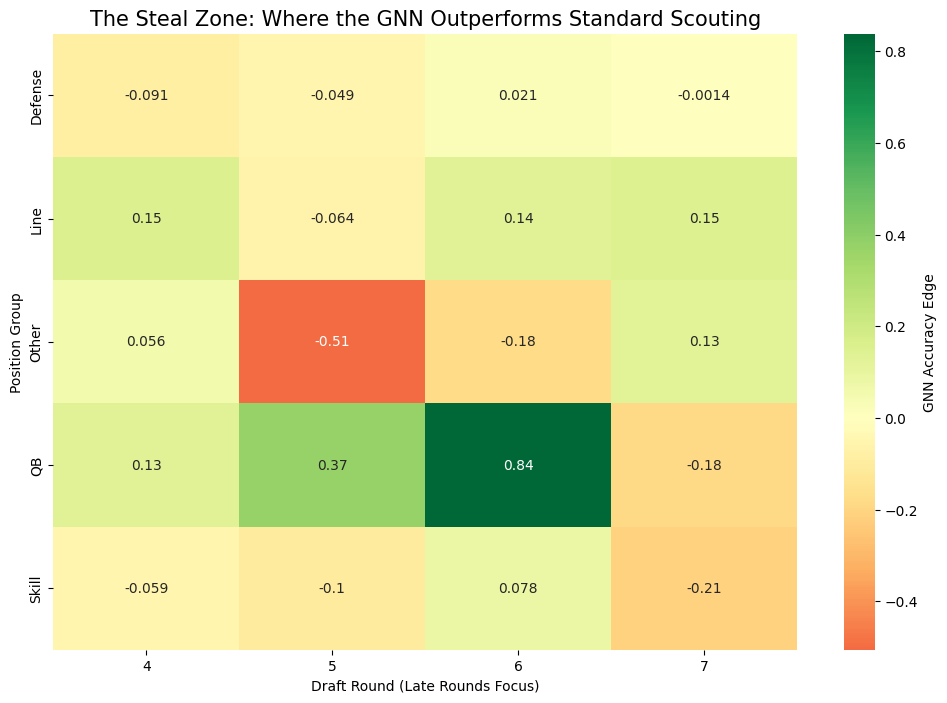

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a pivot table: Average GNN Advantage by Round and Position
# We use GNN_Better_Than_MLP to show where the GNN is 'smarter'
pivot_data = analysis_df[analysis_df['Rnd'] >= 4].pivot_table(
    index='PosGroup',
    columns='Rnd',
    values='GNN_Better_Than_MLP',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn', center=0, cbar_kws={'label': 'GNN Accuracy Edge'})

plt.title("The Steal Zone: Where the GNN Outperforms Standard Scouting", fontsize=15)
plt.xlabel("Draft Round (Late Rounds Focus)")
plt.ylabel("Position Group")
plt.show()

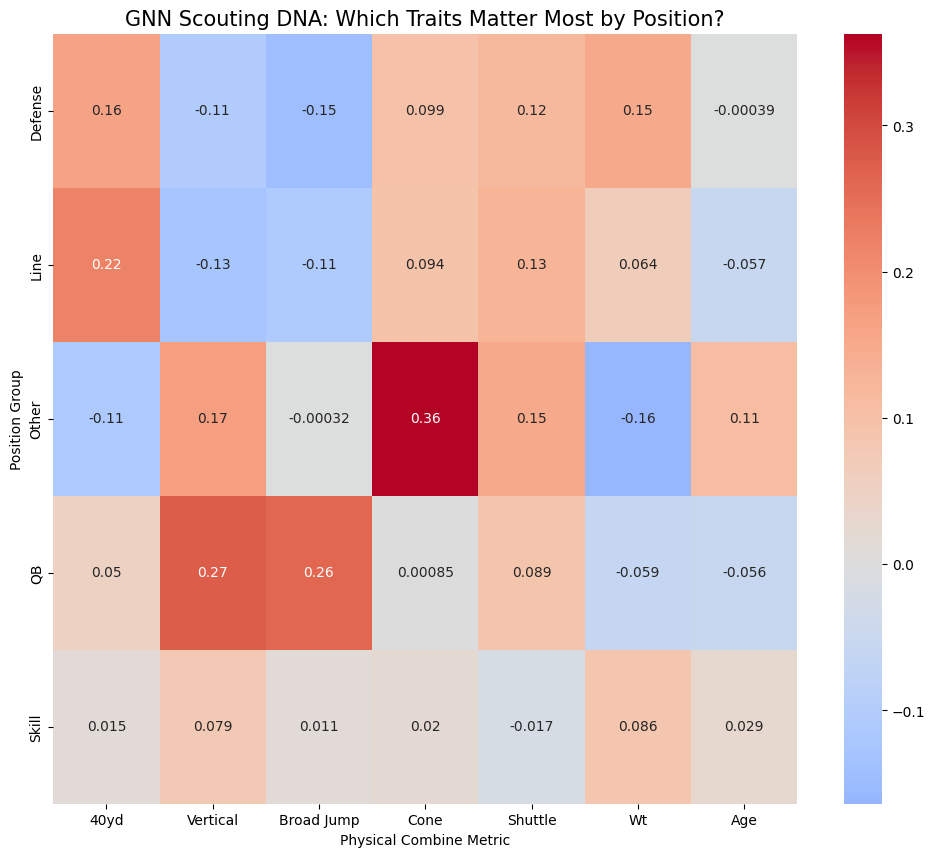

In [ ]:
# List of physical traits we want to analyze
traits = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt', 'Age']

# Calculate correlation of traits vs the GNN Prediction, grouped by Position
# This reveals the 'weighting' the model learned for each spot on the field
trait_corr = analysis_df.groupby('PosGroup')[traits + ['GNN_Pred']].corr()['GNN_Pred'].unstack()

plt.figure(figsize=(12, 10))
# We drop GNN_Pred from the columns so we only see traits vs the prediction
sns.heatmap(trait_corr.drop('GNN_Pred', axis=1), annot=True, cmap='coolwarm', center=0)

plt.title("GNN Scouting DNA: Which Traits Matter Most by Position?", fontsize=15)
plt.xlabel("Physical Combine Metric")
plt.ylabel("Position Group")
plt.show()

In [ ]:
analysis_df.columns

Index(['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St',
       'wAV', 'DrAV', 'G', 'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD',
       'Pass_Int', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rec', 'Rec_Yds',
       'Rec_TD', 'Solo', 'Def_Int', 'Sk', 'College/Univ', 'Misc', 'pfref_id',
       'Season', 'wAVOE', 'PosGroup', '40yd', 'Vertical', 'Broad Jump', 'Cone',
       'Shuttle', 'Wt', 'BroadJump', 'GNN_Pred', 'MLP_Pred', 'Actual_wAVOE',
       'Explosive_Index'],
      dtype='object')

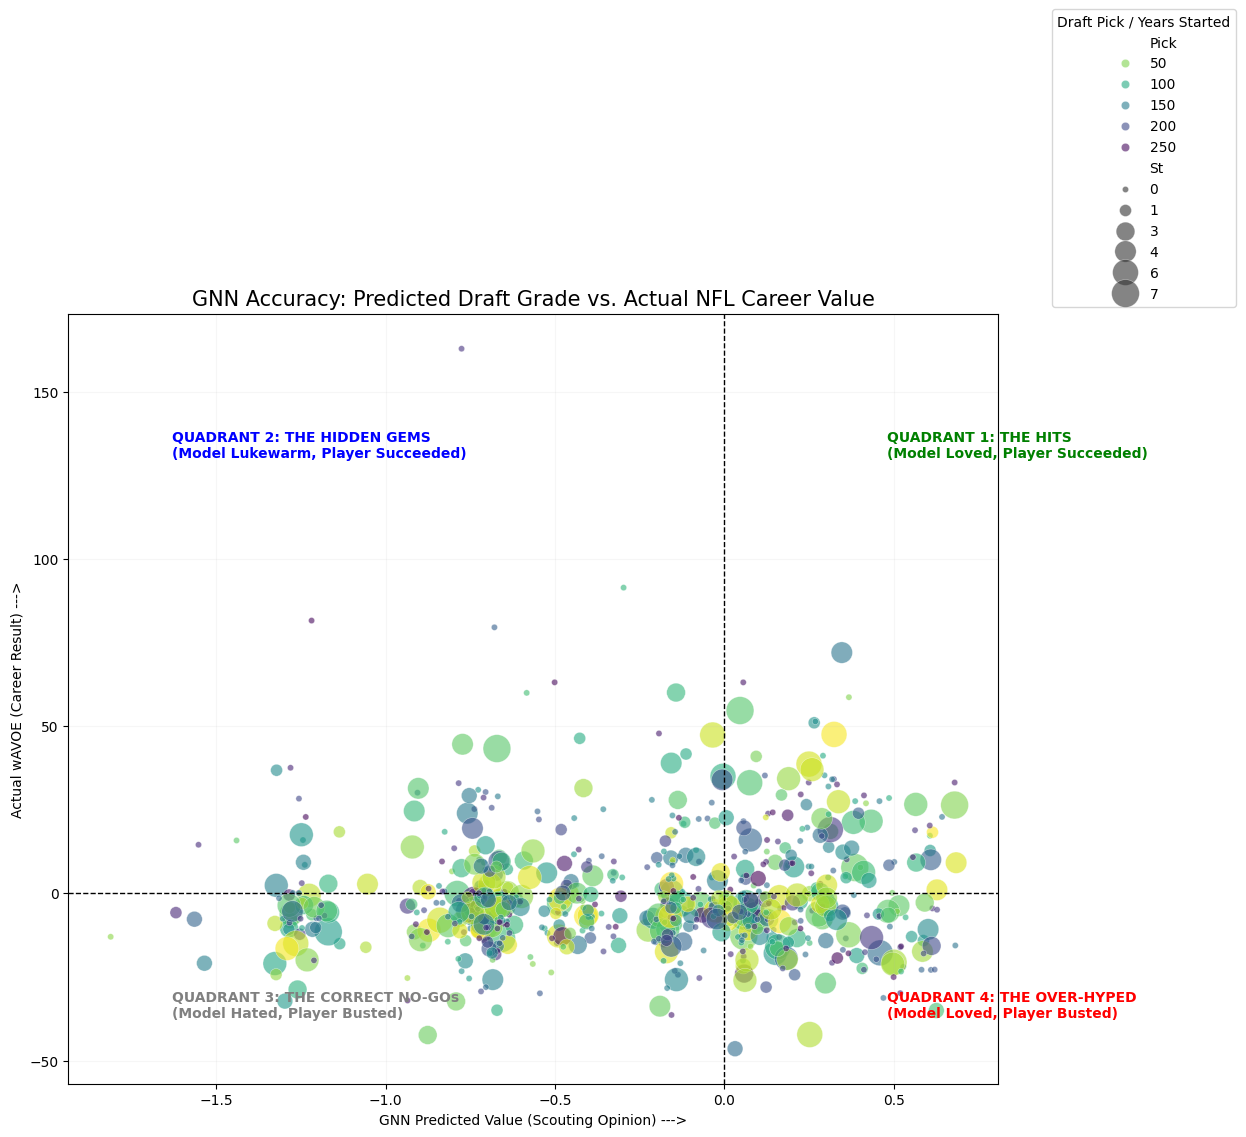

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sync and Calculate (Ensuring columns exist)
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final
analysis_df['Actual_wAVOE'] = y_reg_test

plt.figure(figsize=(12, 10))

# X: What the GNN thought (Predicted Value)
# Y: What actually happened (Actual wAVOE)
# Hue: Pick (Shows if these are early or late rounders)
# Size: St (Number of Years Started)
sns.scatterplot(data=analysis_df, x='GNN_Pred', y='Actual_wAVOE',
                hue='Pick', size='St', sizes=(20, 400),
                palette='viridis_r', alpha=0.6)

# Draw the "Quadrant Lines" at 0,0
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Annotate the Quadrants
plt.text(analysis_df['GNN_Pred'].max()*0.7, analysis_df['Actual_wAVOE'].max()*0.8,
         "QUADRANT 1: THE HITS\n(Model Loved, Player Succeeded)", fontsize=10, weight='bold', color='green')
plt.text(analysis_df['GNN_Pred'].min()*0.9, analysis_df['Actual_wAVOE'].max()*0.8,
         "QUADRANT 2: THE HIDDEN GEMS\n(Model Lukewarm, Player Succeeded)", fontsize=10, weight='bold', color='blue')
plt.text(analysis_df['GNN_Pred'].min()*0.9, analysis_df['Actual_wAVOE'].min()*0.8,
         "QUADRANT 3: THE CORRECT NO-GOs\n(Model Hated, Player Busted)", fontsize=10, weight='bold', color='gray')
plt.text(analysis_df['GNN_Pred'].max()*0.7, analysis_df['Actual_wAVOE'].min()*0.8,
         "QUADRANT 4: THE OVER-HYPED\n(Model Loved, Player Busted)", fontsize=10, weight='bold', color='red')

plt.title("GNN Accuracy: Predicted Draft Grade vs. Actual NFL Career Value", fontsize=15)
plt.xlabel("GNN Predicted Value (Scouting Opinion) --->")
plt.ylabel("Actual wAVOE (Career Result) --->")
plt.legend(title="Draft Pick / Years Started", bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.1)
plt.show()

In [ ]:
# 1. Define the Quadrants in the dataframe
analysis_df['Quadrant'] = 'Unknown'
analysis_df.loc[(analysis_df['GNN_Pred'] > 0) & (analysis_df['Actual_wAVOE'] > 0), 'Quadrant'] = 'Q1: The Hits'
analysis_df.loc[(analysis_df['GNN_Pred'] <= 0) & (analysis_df['Actual_wAVOE'] > 0), 'Quadrant'] = 'Q2: Hidden Gems'
analysis_df.loc[(analysis_df['GNN_Pred'] <= 0) & (analysis_df['Actual_wAVOE'] <= 0), 'Quadrant'] = 'Q3: Correct No-Gos'
analysis_df.loc[(analysis_df['GNN_Pred'] > 0) & (analysis_df['Actual_wAVOE'] <= 0), 'Quadrant'] = 'Q4: Over-Hyped'

# 2. Calculate the Average Traits for each Quadrant
traits = ['40yd', 'Vertical', 'Broad Jump', 'Wt', 'Age', 'Pick']
quadrant_dna = analysis_df.groupby('Quadrant')[traits].mean().round(2)

print("The Scouting DNA of each Quadrant:")
print(quadrant_dna)

The Scouting DNA of each Quadrant:
                    40yd  Vertical  Broad Jump      Wt    Age    Pick
Quadrant                                                             
Q1: The Hits        4.76     33.41      116.94  253.27  22.28  137.56
Q2: Hidden Gems     4.71     33.88      118.61  240.29  22.41  136.85
Q3: Correct No-Gos  4.72     33.52      117.84  242.71  22.27  130.45
Q4: Over-Hyped      4.77     33.36      116.86  246.98  22.32  134.73


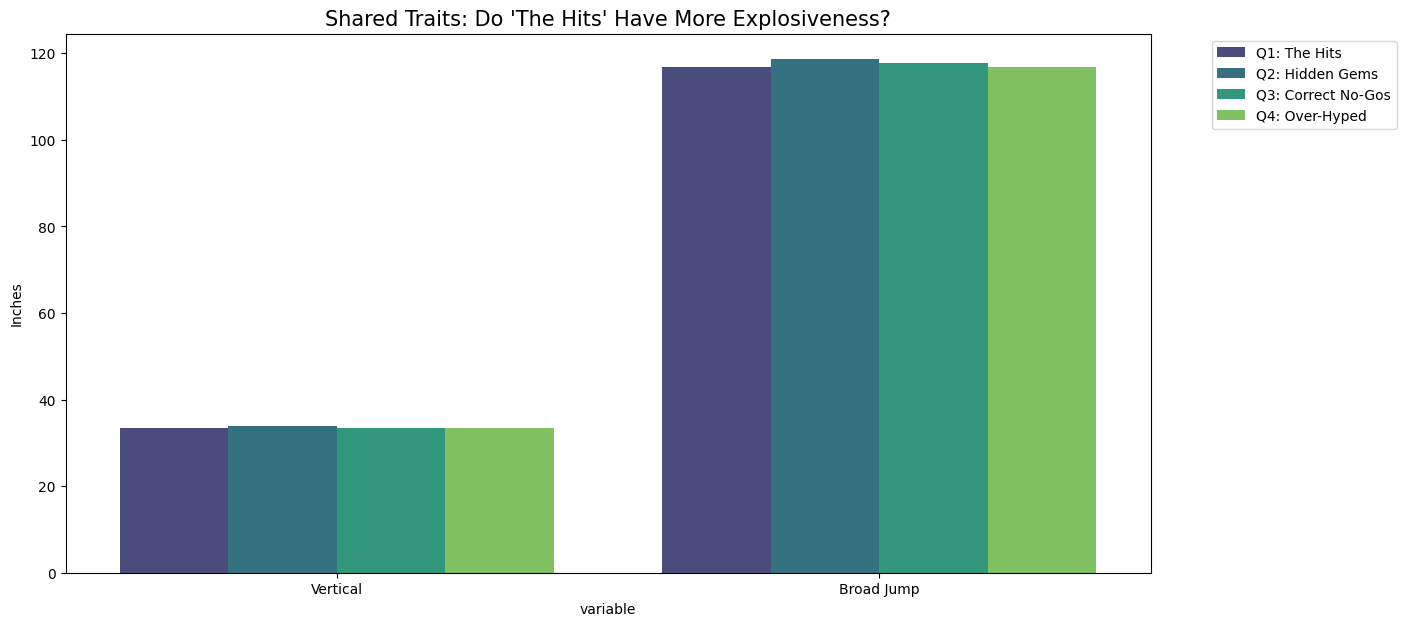

In [ ]:
# Melt the data to make it 'Long Form' for Seaborn
dna_melted = quadrant_dna.reset_index().melt(id_vars='Quadrant')

plt.figure(figsize=(14, 7))
# We'll plot Vertical and Broad Jump as examples of 'Explosiveness'
explosive_traits = dna_melted[dna_melted['variable'].isin(['Vertical', 'Broad Jump'])]

sns.barplot(data=explosive_traits, x='variable', y='value', hue='Quadrant', palette='viridis')
plt.title("Shared Traits: Do 'The Hits' Have More Explosiveness?", fontsize=15)
plt.ylabel("Inches")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

--- The Scouting DNA of each Quadrant ---
                    40yd  Vertical  Broad Jump      Wt    Age    Pick
Quadrant                                                             
Q1: The Hits        4.76     33.41      116.94  253.27  22.28  137.56
Q2: Hidden Gems     4.71     33.88      118.61  240.29  22.41  136.85
Q3: Correct No-Gos  4.72     33.52      117.84  242.71  22.27  130.45
Q4: Over-Hyped      4.77     33.36      116.86  246.98  22.32  134.73


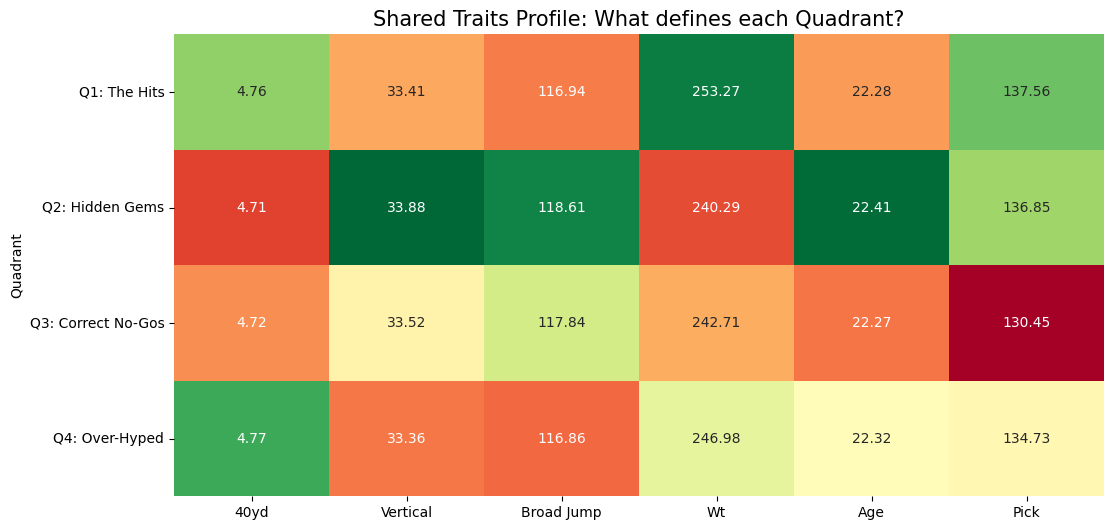

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sync metadata with predictions
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final
analysis_df['Actual_wAVOE'] = y_reg_test

# 2. Assign Quadrants
analysis_df['Quadrant'] = 'Unknown'
analysis_df.loc[(analysis_df['GNN_Pred'] > 0) & (analysis_df['Actual_wAVOE'] > 0), 'Quadrant'] = 'Q1: The Hits'
analysis_df.loc[(analysis_df['GNN_Pred'] <= 0) & (analysis_df['Actual_wAVOE'] > 0), 'Quadrant'] = 'Q2: Hidden Gems'
analysis_df.loc[(analysis_df['GNN_Pred'] <= 0) & (analysis_df['Actual_wAVOE'] <= 0), 'Quadrant'] = 'Q3: Correct No-Gos'
analysis_df.loc[(analysis_df['GNN_Pred'] > 0) & (analysis_df['Actual_wAVOE'] <= 0), 'Quadrant'] = 'Q4: Over-Hyped'

# 3. Define the traits we want to compare
traits = ['40yd', 'Vertical', 'Broad Jump', 'Wt', 'Age', 'Pick']

# Calculate averages for each quadrant
quadrant_stats = analysis_df.groupby('Quadrant')[traits].mean().round(2)

print("--- The Scouting DNA of each Quadrant ---")
print(quadrant_stats)

# 4. Visualize the comparison (Normalization for better viewing)
# We'll normalize stats so they fit on one chart
df_norm = (quadrant_stats - quadrant_stats.mean()) / quadrant_stats.std()
plt.figure(figsize=(12, 6))
sns.heatmap(df_norm, annot=quadrant_stats, cmap='RdYlGn', fmt='.2f', cbar=False)
plt.title("Shared Traits Profile: What defines each Quadrant?", fontsize=15)
plt.show()

In [ ]:
# Check the unique names in your position columns
print("Positions in 'Pos':", raw_data_full['Pos'].unique())
if 'PosGroup' in raw_data_full.columns:
    print("Positions in 'PosGroup':", raw_data_full['PosGroup'].unique())

Positions in 'Pos': ['DE' 'LB' 'T' 'WR' 'RB' 'DT' 'TE' 'DB' 'K' 'QB' 'G' 'C' 'FB' 'P' 'NT'
 'OL' 'DL' 'OLB' 'CB' 'S' 'ILB' 'LS']
Positions in 'PosGroup': ['Defense' 'Line' 'Skill' 'Other' 'QB' 'Big Skill']


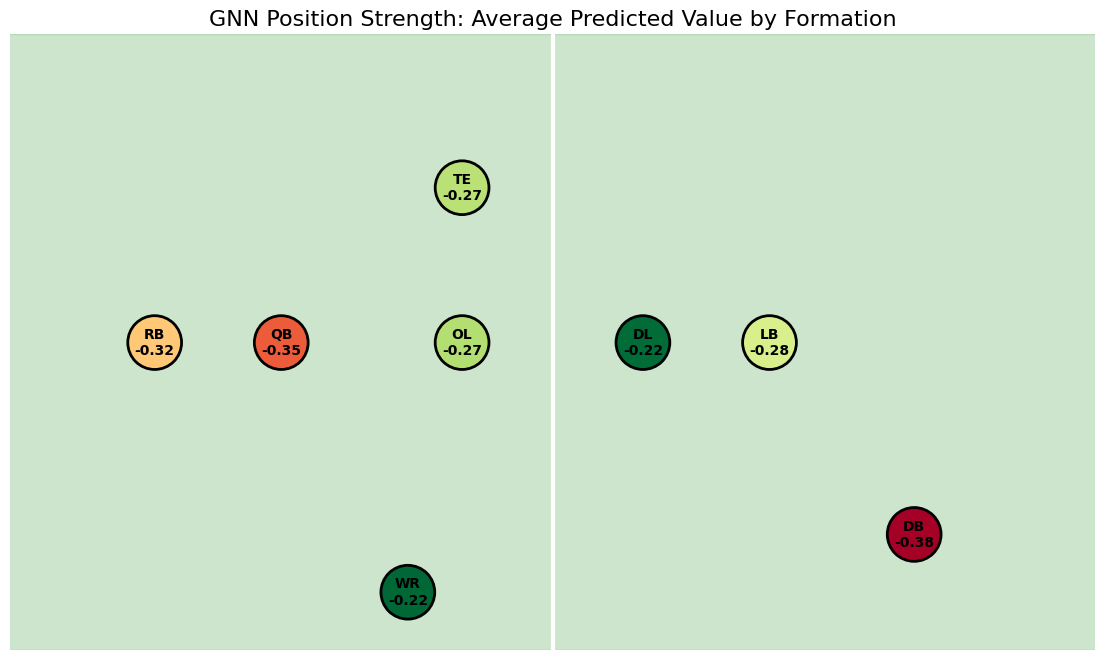

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# 1. Re-sync Data
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final

# 2. Robust Position Mapping (Group specific roles into Field Spots)
field_map = {
    'QB': 'QB', 'RB': 'RB', 'FB': 'RB',
    'WR': 'WR', 'TE': 'TE',
    'OT': 'OL', 'OG': 'OL', 'C': 'OL',
    'DE': 'DL', 'DT': 'DL', 'NT': 'DL',
    'LB': 'LB', 'ILB': 'LB', 'OLB': 'LB',
    'CB': 'DB', 'S': 'DB', 'SAF': 'DB', 'FS': 'DB', 'SS': 'DB'
}

analysis_df['Field_Pos'] = analysis_df['Pos'].map(field_map)

# 3. Define Clean Coordinates (X, Y) for a standard 11-man look
# Offense stays on left (x < 50), Defense on right (x > 50)
coords = {
    'QB': (35, 26.6), 'RB': (28, 26.6), 'WR': (42, 5), 'TE': (45, 40), 'OL': (45, 26.6),
    'DL': (55, 26.6), 'LB': (62, 26.6), 'DB': (70, 10)
}

# 4. Aggregate: Find the average GNN score for each Field Position
field_stats = analysis_df.groupby('Field_Pos')['GNN_Pred'].mean().reset_index()
field_stats['x'] = field_stats['Field_Pos'].map(lambda x: coords[x][0] if x in coords else None)
field_stats['y'] = field_stats['Field_Pos'].map(lambda x: coords[x][1] if x in coords else None)
field_stats = field_stats.dropna()

# 5. Build the Visual
fig, ax = plt.subplots(figsize=(14, 8))

# Draw the Field
ax.add_patch(patches.Rectangle((0, 0), 100, 53.3, color='green', alpha=0.2))
ax.axvline(50, color='white', linewidth=3) # Line of Scrimmage

# Plot the "Average Talent" by Position
sc = ax.scatter(field_stats['x'], field_stats['y'], c=field_stats['GNN_Pred'],
                s=1500, cmap='RdYlGn', edgecolors='black', linewidth=2)

# Label the groups
for i, row in field_stats.iterrows():
    ax.text(row['x'], row['y'], f"{row['Field_Pos']}\n{row['GNN_Pred']:.2f}",
            ha='center', va='center', weight='bold', color='black', fontsize=10)

plt.title("GNN Position Strength: Average Predicted Value by Formation", fontsize=16)
plt.xlim(20, 80) # Zoom into the action
plt.ylim(0, 53.3)
plt.axis('off')
plt.show()

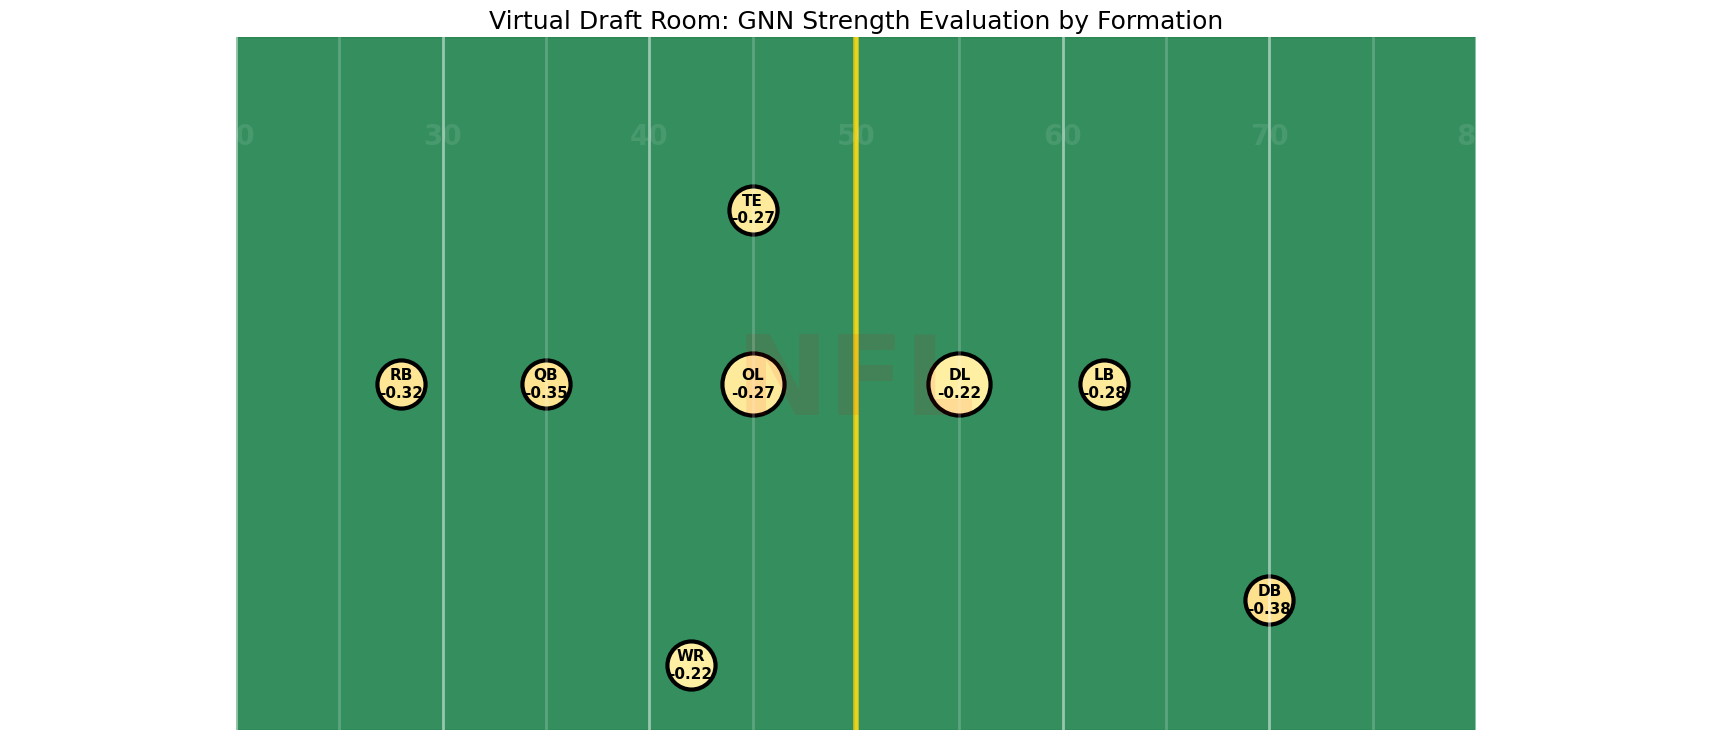

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

# 1. Sync and Map Positions (Making it robust for empty spots)
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final

# Map with Fallbacks for empty positions
robust_map = {
    'QB': 'QB', 'RB': 'RB', 'FB': 'RB',
    'WR': 'WR', 'TE': 'TE',
    'OT': 'OL', 'OG': 'OL', 'C': 'OL',
    'DE': 'DL', 'DT': 'DL', 'NT': 'DL',
    'LB': 'LB', 'ILB': 'LB', 'OLB': 'LB',
    'CB': 'DB', 'S': 'DB', 'SAF': 'DB', 'FS': 'DB', 'SS': 'DB'
}
analysis_df['Field_Pos'] = analysis_df['Pos'].map(robust_map)

# 2. Define Clean coordinates and standard positions for a full look
coords = {
    'QB': (35, 26.6), 'RB': (28, 26.6), 'WR': (42, 5), 'TE': (45, 40), 'OL': (45, 26.6),
    'DL': (55, 26.6), 'LB': (62, 26.6), 'DB': (70, 10)
}

# Find Average Strength for positions that EXIST
field_stats = analysis_df.groupby('Field_Pos')['GNN_Pred'].mean().reset_index()
available_pos = set(field_stats['Field_Pos'].unique())

# 3. Create the GNN Field with Turf and Details
fig, ax = plt.subplots(figsize=(16, 9))

# Draw the "Turf"
ax.add_patch(patches.Rectangle((0, 0), 100, 53.3, color='#1e824c', alpha=0.9)) # Turf green

# Draw detailed Yard Lines and Tick Marks
for x in range(0, 105, 5):
    line_alpha = 0.5 if x % 10 == 0 else 0.2
    ax.axvline(x, color='white', linewidth=2, alpha=line_alpha)
    if x > 0 and x < 100 and x % 10 == 0:
        # Add a Faded Yard Number
        ax.text(x, 45, str(x), color='white', alpha=0.1, fontsize=20, weight='bold', ha='center')

# Line of Scrimmage (Midfield)
ax.axvline(50, color='gold', linewidth=4, alpha=0.8)

# Simulating the NFL Shield at midfield (Faded watermark)
ax.text(50, 26.6, "NFL", color='red', alpha=0.08, fontsize=80, weight='bold', ha='center', va='center')

# 4. Plot the positions (Both 'GNN Grades' and 'Placeholders')
for pos, (x, y) in coords.items():
    if pos in available_pos:
        # Data Exists: Plot GNN Grade
        pred_val = field_stats[field_stats['Field_Pos'] == pos]['GNN_Pred'].values[0]
        color = plt.cm.RdYlGn((pred_val + 2.0) / 4.0) # Mapping value to color spectrum
        s_val = 2000 if pos == 'OL' or pos == 'DL' else 1200 # OL/DL are larger circles
        ax.scatter(x, y, s=s_val, color=color, edgecolors='black', linewidth=3)
        ax.text(x, y, f"{pos}\n{pred_val:.2f}", ha='center', va='center', weight='bold', color='black', fontsize=11)
    else:
        # Data is missing: Plot Placeholder (Gray/Faded)
        ax.scatter(x, y, s=1000, color='gray', edgecolors='white', linewidth=1, alpha=0.3)
        ax.text(x, y, pos, ha='center', va='center', weight='normal', color='white', alpha=0.5, fontsize=10)

plt.title("Virtual Draft Room: GNN Strength Evaluation by Formation", fontsize=18)
plt.xlim(20, 80) # Focus on the middle of the field
plt.ylim(0, 53.3)
plt.axis('off')
plt.grid(False)
plt.show()

Text(0.5, 1.0, 'Deep Dive: Does Speed Predict Late-Round Hits')

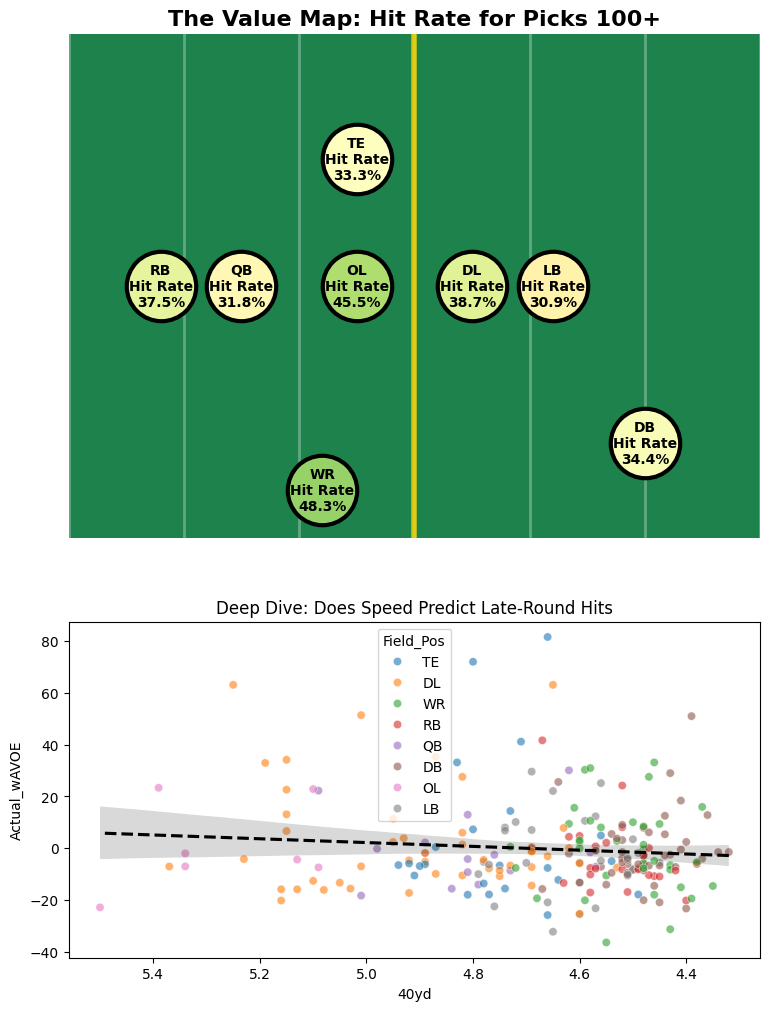

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# 1. THE RECHARGE: Re-sync and define the "Hit" metric
analysis_df = raw_data_full.iloc[-len(gnn_final):].copy()
analysis_df['GNN_Pred'] = gnn_final
analysis_df['Actual_wAVOE'] = y_reg_test
# A "Hit" is anyone who performed better than their draft slot (wAVOE > 0)
analysis_df['Is_Hit'] = (analysis_df['Actual_wAVOE'] > 0).astype(int)

# 2. POSITION MAPPING (Ensuring we catch everyone)
robust_map = {
    'QB': 'QB', 'RB': 'RB', 'FB': 'RB', 'WR': 'WR', 'TE': 'TE',
    'OT': 'OL', 'OG': 'OL', 'C': 'OL', 'DE': 'DL', 'DT': 'DL',
    'LB': 'LB', 'CB': 'DB', 'S': 'DB', 'SAF': 'DB'
}
analysis_df['Field_Pos'] = analysis_df['Pos'].map(robust_map)

# 3. FILTER: Picks 100+ (The Value Zone)
value_df = analysis_df[analysis_df['Pick'] >= 100].dropna(subset=['Field_Pos']).copy()

# 4. CALCULATE: Hit Rate by Position
hit_rates = value_df.groupby('Field_Pos')['Is_Hit'].mean().reset_index()

# 5. THE DASHBOARD
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], width_ratios=[1.2, 1])

# --- PLOT A: THE TURF MAP (Hit Rate %) ---
ax_field = fig.add_subplot(gs[0, 0])
ax_field.set_facecolor('#1e824c')
ax_field.add_patch(patches.Rectangle((0, 0), 100, 53.3, color='#1e824c', zorder=0))

# Draw Field Details
for x in range(0, 110, 10):
    ax_field.axvline(x, color='white', alpha=0.3, lw=2)
ax_field.axvline(50, color='gold', lw=4, alpha=0.8) # Scrimmage Line

# Plot Position Hit Rates
for pos, (x, y) in coords.items():
    if pos in hit_rates['Field_Pos'].values:
        rate = hit_rates[hit_rates['Field_Pos'] == pos]['Is_Hit'].values[0]
        color = plt.cm.RdYlGn(rate * 1.5) # Scale color by hit rate
        ax_field.scatter(x, y, s=2500, color=color, edgecolors='black', lw=3, zorder=3)
        ax_field.text(x, y, f"{pos}\nHit Rate\n{rate:.1%}", ha='center', va='center', weight='bold')
    else:
        ax_field.scatter(x, y, s=1500, color='gray', alpha=0.2, zorder=1)

ax_field.set_title("The Value Map: Hit Rate for Picks 100+", fontsize=16, weight='bold')
ax_field.set_xlim(20, 80); ax_field.set_ylim(0, 53.3); ax_field.axis('off')

# --- PLOT B: THE DEEPER DIVE (Trait Correlation) ---
ax_dive = fig.add_subplot(gs[1, 0])
# Let's look at 40yd dash vs Value for these late rounders
sns.scatterplot(data=value_df, x='40yd', y='Actual_wAVOE', hue='Field_Pos', ax=ax_dive, alpha=0.6)
sns.regplot(data=value_df, x='40yd', y='Actual_wAVOE', scatter=False, ax=ax_dive, color='black', line_kws={'ls':'--'})
ax_dive.invert_xaxis() # Faster is lower
ax_dive.set_title("Deep Dive: Does Speed Predict Late-Round Hits")

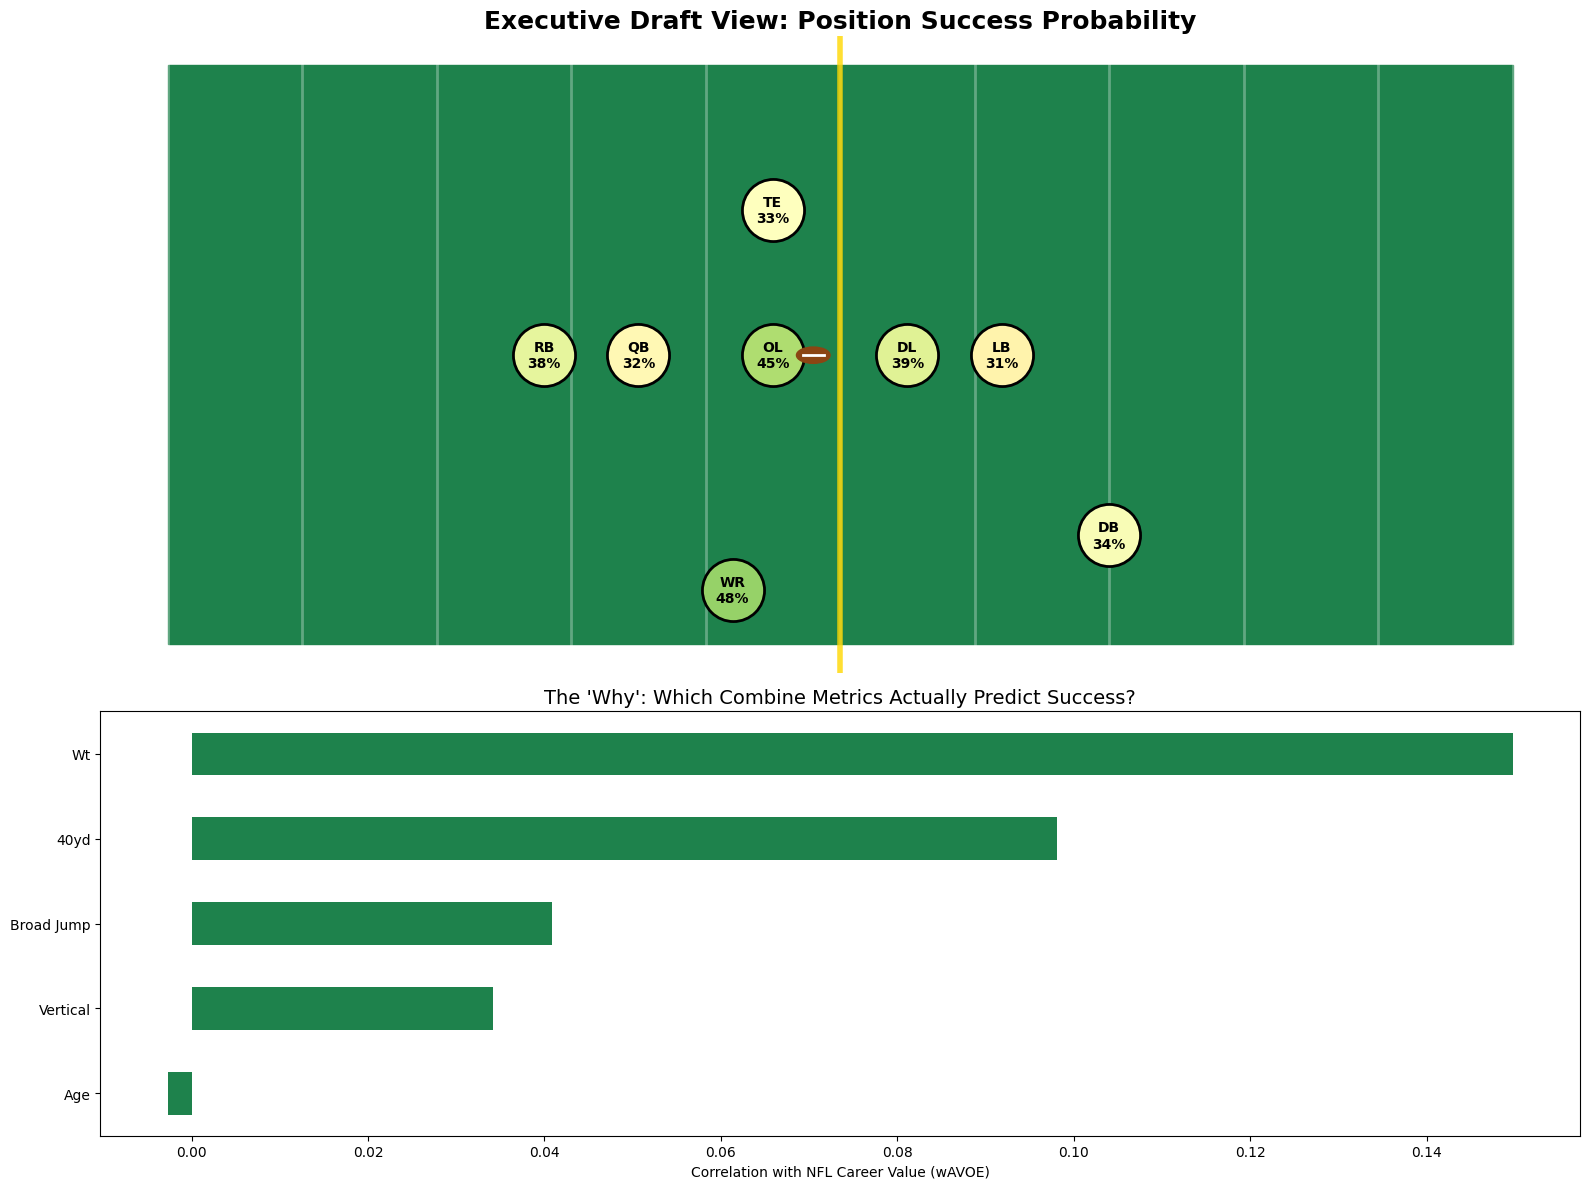

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# 1. SETUP THE DASHBOARD
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1])

# --- PANEL A: THE FIELD WITH PROP FOOTBALL ---
ax_field = fig.add_subplot(gs[0, 0])
ax_field.set_facecolor('#1e824c')
ax_field.add_patch(patches.Rectangle((0, 0), 100, 53.3, color='#1e824c', zorder=0))

# Yard Lines
for x in range(0, 110, 10):
    ax_field.axvline(x, color='white', alpha=0.3, lw=2)
ax_field.axvline(50, color='gold', lw=4, alpha=0.8)

# ADD THE "PROP" FOOTBALL (At the 48-yard line)
fb_x, fb_y = 48, 26.6
football_body = patches.Ellipse((fb_x, fb_y), 2.5, 1.5, color='#8B4513', zorder=5)
ax_field.add_patch(football_body)
# White laces
ax_field.plot([fb_x-0.8, fb_x+0.8], [fb_y, fb_y], color='white', lw=2, zorder=6)

# Plot the Position Groups (Colored by Hit Rate)
for pos, (x, y) in coords.items():
    if pos in hit_rates['Field_Pos'].values:
        rate = hit_rates[hit_rates['Field_Pos'] == pos]['Is_Hit'].values[0]
        ax_field.scatter(x, y, s=2000, color=plt.cm.RdYlGn(rate*1.5), edgecolors='black', lw=2, zorder=3)
        ax_field.text(x, y, f"{pos}\n{rate:.0%}", ha='center', va='center', weight='bold')

ax_field.set_title("Executive Draft View: Position Success Probability", fontsize=18, weight='bold')
ax_field.axis('off')

# --- PANEL B: THE STAKEHOLDER'S ANSWER (What matters?) ---
# We calculate correlation between ALL traits and the Actual Value
# This tells the stakeholder: "This is what drives winning in the NFL."
ax_logic = fig.add_subplot(gs[1, 0])
correlations = value_df[['40yd', 'Vertical', 'Broad Jump', 'Wt', 'Age', 'Actual_wAVOE']].corr()['Actual_wAVOE'].drop('Actual_wAVOE')
correlations.sort_values().plot(kind='barh', color='#1e824c', ax=ax_logic)

ax_logic.set_title("The 'Why': Which Combine Metrics Actually Predict Success?", fontsize=14)
ax_logic.set_xlabel("Correlation with NFL Career Value (wAVOE)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1910/1807136202.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Rnd', y='GNN_Pred', palette='RdYlGn')


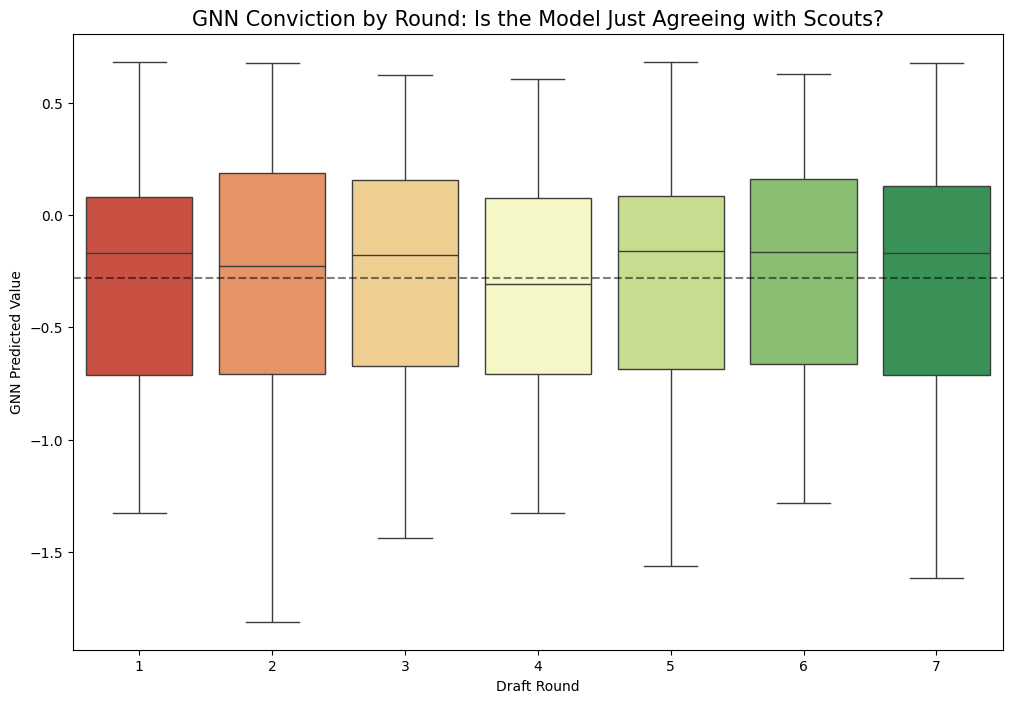

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot GNN Prediction against Draft Round
plt.figure(figsize=(12, 8))
sns.boxplot(data=analysis_df, x='Rnd', y='GNN_Pred', palette='RdYlGn')

plt.title("GNN Conviction by Round: Is the Model Just Agreeing with Scouts?", fontsize=15)
plt.xlabel("Draft Round")
plt.ylabel("GNN Predicted Value")
plt.axhline(analysis_df['GNN_Pred'].mean(), color='black', linestyle='--', alpha=0.5)
plt.show()